# Manufacturing Defect Analysis with Python

This notebook explores a synthetic manufacturing defect dataset using Python, pandas, matplotlib, seaborn, scipy, and scikit-learn. The goal is to understand how production, quality, maintenance, and workforce-related variables may relate to defect outcomes through exploratory analysis, statistical checks, and baseline classification models.


## Report Roadmap and Analytical Logic

This report is organized as an exploratory manufacturing quality analysis. The first part checks the structure and reliability of the dataset, including the number of records, available variables, missing values, and the balance between low-defect and high-defect observations. This matters because a quality analysis should first confirm that the dataset is usable before interpreting patterns.

The second part studies the outcome variables: `DefectRate`, which is a continuous measure of defect level, and `DefectStatus`, which classifies records as low-defect or high-defect. Looking at both outcomes is useful because continuous defect rate shows the severity of defects, while defect status supports group comparison and classification-style analysis.

The third part compares production, quality, maintenance, supplier, inventory, workforce, energy, and additive-manufacturing variables between low-defect and high-defect records. This helps identify which process areas differ most between the two groups.

The fourth part adds statistical and modeling checks. Statistical tests help determine whether observed group differences are likely to be meaningful, while a simple baseline classification model checks whether the variables can jointly distinguish high-defect records from low-defect records. Because the data is synthetic, these results should be interpreted as analytical evidence inside this dataset rather than as real-world causal conclusions.


## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import seaborn as sns

from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)
from sklearn.inspection import permutation_importance

plt.style.use("default")
sns.set_theme(style="whitegrid")


## 2. Load Dataset

In [42]:
df = pd.read_csv ("../data/manufacturing_defect_dataset.csv")

## 3. Initial Dataset Inspection

In [4]:
df.head()

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   int64  
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   int64  
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   int64  
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   int64  
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   3240 non-null   float64
 15  AdditiveMaterialCost 

In [6]:
df.describe ()

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
count,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000
mean,548.523148,12423.018476,89.833290,2.558951,2.749116,80.134272,11.476543,2.501373,6.019662,0.050878,90.040115,4.591667,2988.494453,0.299776,5.472098,299.515479,0.840432
std,262.402073,4308.051904,5.759143,1.705804,1.310154,11.611750,6.872684,1.443684,2.329791,0.028797,5.723600,2.896313,1153.420820,0.116400,2.598212,116.379905,0.366261
min,100.000000,5000.174521,80.004820,0.000000,0.500710,60.010098,0.000000,0.001665,2.001611,0.000002,80.004960,0.000000,1000.720156,0.100238,1.000151,100.211137,0.000000
25%,322.000000,8728.829280,84.869219,1.000000,1.598033,70.103420,5.750000,1.264597,3.983249,0.026200,85.180203,2.000000,1988.140273,0.200502,3.228507,194.922058,1.000000
50%,549.000000,12405.204656,89.704861,3.000000,2.708775,80.265312,12.000000,2.465151,6.022389,0.051837,90.125743,5.000000,2996.822301,0.297470,5.437134,299.728918,1.000000
75%,775.250000,16124.462428,94.789936,4.000000,3.904533,90.353822,17.000000,3.774861,8.050222,0.075473,95.050838,7.000000,3984.788299,0.402659,7.741006,403.178283,1.000000
max,999.000000,19993.365549,99.989214,5.000000,4.998529,99.996993,23.000000,4.997591,9.998577,0.099997,99.996786,9.000000,4997.074741,0.499500,9.999749,499.982782,1.000000


## 4. Dataset Overview

Before deeper analysis, I check the dataset size, column names, and missing values to understand the structure and reliability of the data.

In [7]:
df.shape

(3240, 17)

In [8]:
df.columns

Index(['ProductionVolume', 'ProductionCost', 'SupplierQuality',
       'DeliveryDelay', 'DefectRate', 'QualityScore', 'MaintenanceHours',
       'DowntimePercentage', 'InventoryTurnover', 'StockoutRate',
       'WorkerProductivity', 'SafetyIncidents', 'EnergyConsumption',
       'EnergyEfficiency', 'AdditiveProcessTime', 'AdditiveMaterialCost',
       'DefectStatus'],
      dtype='object')

The dataset includes variables related to production volume, cost, supplier quality, delivery, defect rate, maintenance, downtime, inventory, productivity, safety, energy efficiency, additive manufacturing, and defect status.

In [9]:
df.isna().sum()

ProductionVolume        0
ProductionCost          0
SupplierQuality         0
DeliveryDelay           0
DefectRate              0
QualityScore            0
MaintenanceHours        0
DowntimePercentage      0
InventoryTurnover       0
StockoutRate            0
WorkerProductivity      0
SafetyIncidents         0
EnergyConsumption       0
EnergyEfficiency        0
AdditiveProcessTime     0
AdditiveMaterialCost    0
DefectStatus            0
dtype: int64

The dataset contains 3,240 records and 17 columns. The selected variables include production, quality, maintenance, supplier, inventory, and workforce-related metrics. There are no missing values in the dataset, which makes it suitable for initial exploratory analysis.

### Feature Groups and Manufacturing Meaning

The variables in this dataset can be interpreted as different parts of a manufacturing system:

| Feature group | Columns | What the group represents |
|---|---|---|
| Production scale and cost | `ProductionVolume`, `ProductionCost` | How much is produced and how expensive production is |
| Supplier and delivery | `SupplierQuality`, `DeliveryDelay` | Input quality and supply-chain reliability |
| Quality outcome | `DefectRate`, `QualityScore`, `DefectStatus` | Product quality and defect classification |
| Maintenance and downtime | `MaintenanceHours`, `DowntimePercentage` | Equipment condition, repair effort, and lost operating time |
| Inventory | `InventoryTurnover`, `StockoutRate` | Material availability and inventory efficiency |
| Workforce and safety | `WorkerProductivity`, `SafetyIncidents` | Labor performance and workplace stability |
| Energy | `EnergyConsumption`, `EnergyEfficiency` | Resource usage and operating efficiency |
| Additive manufacturing | `AdditiveProcessTime`, `AdditiveMaterialCost` | Process time and material cost for additive operations |

This grouping makes the analysis easier to interpret because it connects each numerical column back to a real manufacturing concept. Instead of treating the dataset as a list of unrelated numbers, the rest of the notebook asks which manufacturing areas are most associated with high-defect outcomes.


In [10]:
feature_groups = {
    "Production": ["ProductionVolume", "ProductionCost"],
    "Supplier and delivery": ["SupplierQuality", "DeliveryDelay"],
    "Quality": ["DefectRate", "QualityScore", "DefectStatus"],
    "Maintenance": ["MaintenanceHours", "DowntimePercentage"],
    "Inventory": ["InventoryTurnover", "StockoutRate"],
    "Workforce and safety": ["WorkerProductivity", "SafetyIncidents"],
    "Energy": ["EnergyConsumption", "EnergyEfficiency"],
    "Additive manufacturing": ["AdditiveProcessTime", "AdditiveMaterialCost"],
}

pd.DataFrame(
    [(group, ", ".join(cols)) for group, cols in feature_groups.items()],
    columns=["Feature Group", "Columns"]
)


,Feature Group,Columns
0,Production,"ProductionVolume, ProductionCost"
1,Supplier and delivery,"SupplierQuality, DeliveryDelay"
2,Quality,"DefectRate, QualityScore, DefectStatus"
3,Maintenance,"MaintenanceHours, DowntimePercentage"
4,Inventory,"InventoryTurnover, StockoutRate"
5,Workforce and safety,"WorkerProductivity, SafetyIncidents"
6,Energy,"EnergyConsumption, EnergyEfficiency"
7,Additive manufacturing,"AdditiveProcessTime, AdditiveMaterialCost"


## 5. First Exploratory Data Analysis

In [11]:
df["DefectStatus"].value_counts()

DefectStatus
1    2723
0     517
Name: count, dtype: int64

The dataset is imbalanced: high-defect records are much more common than low-defect records. This matters because group comparisons may be influenced by the much larger number of high-defect observations. Therefore, later analysis compares averages, medians, and distributions rather than relying only on raw counts.

### Class Balance Check

Before comparing low-defect and high-defect records, I calculate both counts and percentages for `DefectStatus`. This is important because the dataset is imbalanced: if one class is much larger than the other, raw counts and accuracy-based conclusions can be misleading.

For this dataset, high-defect records are the majority class. That means a simple model could get a high accuracy score by mostly predicting the majority class. Later, the modeling section uses precision, recall, F1-score, ROC-AUC, and average precision so the evaluation is not based only on accuracy.


In [12]:
status_distribution = pd.DataFrame({
    "Count": df["DefectStatus"].value_counts().sort_index(),
    "Percent": df["DefectStatus"].value_counts(normalize=True).sort_index() * 100
})

status_distribution.index = ["Low Defect (0)", "High Defect (1)"]
status_distribution.round(2)


,Count,Percent
Low Defect (0),517,15.96
High Defect (1),2723,84.04


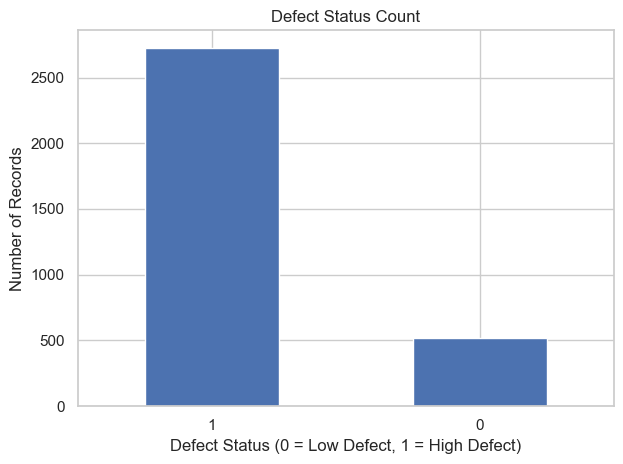

In [13]:
df["DefectStatus"].value_counts().plot (kind="bar")

plt.title("Defect Status Count")
plt.xlabel("Defect Status (0 = Low Defect, 1 = High Defect)")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout ()
plt.show()

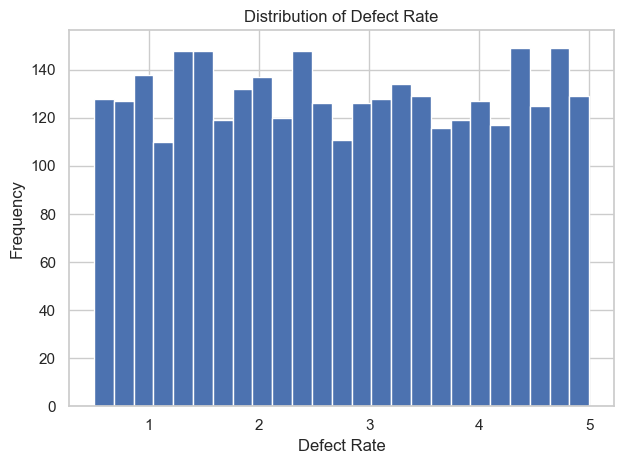

In [14]:
df["DefectRate"].plot(kind="hist", bins=25)

plt.title("Distribution of Defect Rate")
plt.xlabel("Defect Rate")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

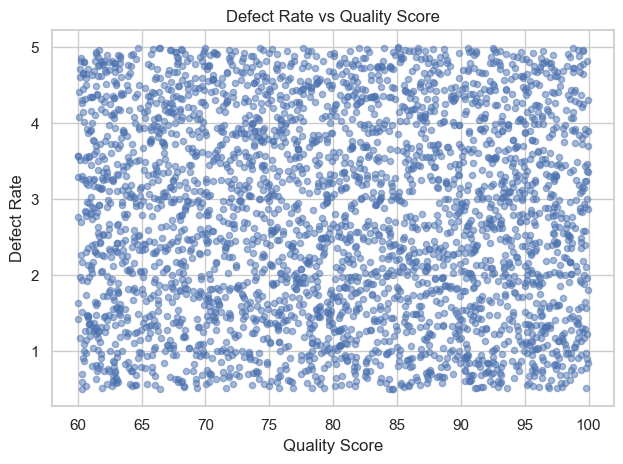

In [15]:
df.plot(x="QualityScore", y="DefectRate", kind="scatter", alpha=0.5)

plt.title("Defect Rate vs Quality Score")
plt.xlabel("Quality Score")
plt.ylabel("Defect Rate")
plt.tight_layout()
plt.show()

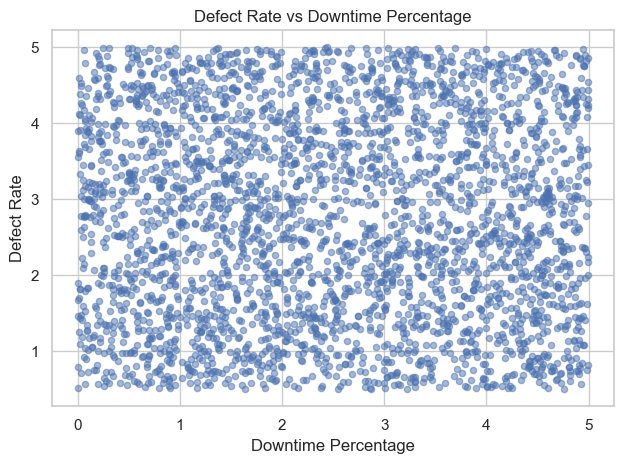

In [16]:
df.plot (x="DowntimePercentage", y="DefectRate", kind="scatter", alpha=0.5)

plt.title("Defect Rate vs Downtime Percentage")
plt.xlabel("Downtime Percentage")
plt.ylabel("Defect Rate")
plt.tight_layout()
plt.show()

## 6. Scatter Plot Observations


The scatter plots for `DefectRate` vs `QualityScore` and `DefectRate` vs `DowntimePercentage` appear widely dispersed. There is no clear linear pattern visible from these two plots alone.

This suggests that defect rate may not be explained by a single variable in isolation. Instead, defect outcomes may be related to a combination of production, quality, maintenance, supplier, and workforce factors.

These plots are exploratory and show possible associations, not causation.

### Enhanced Distribution View

The histogram of `DefectRate` shows the overall spread of defect rates, but it does not show whether low-defect and high-defect records occupy different parts of the distribution. The next plot overlays the two `DefectStatus` groups so the comparison is more direct.

This view helps answer a more specific question: do high-defect records simply have a higher average, or is the entire distribution shifted compared with low-defect records?


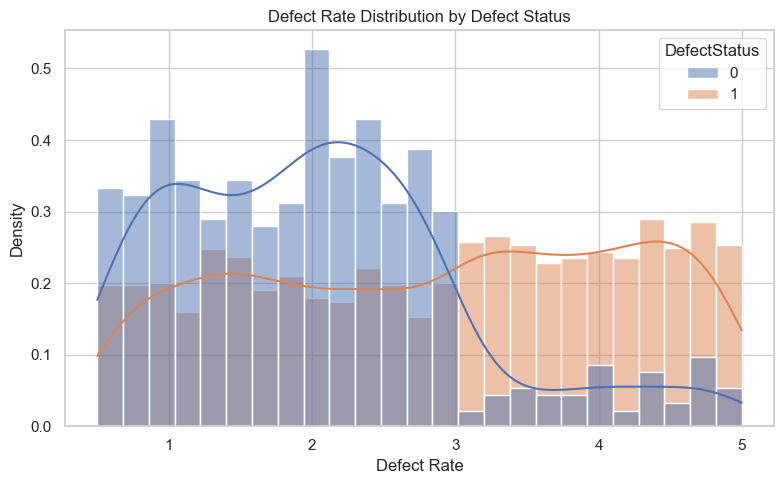

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="DefectRate",
    hue="DefectStatus",
    bins=25,
    kde=True,
    stat="density",
    common_norm=False,
)
plt.title("Defect Rate Distribution by Defect Status")
plt.xlabel("Defect Rate")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


## 7. Grouped Analysis by Defect Status

Since the scatter plots did not show clear single-variable patterns, I compare average values between low-defect and high-defect records using `DefectStatus`.

In [18]:
grouped_means = df.groupby("DefectStatus")[[
    "DefectRate",
    "QualityScore",
    "DowntimePercentage",
    "SupplierQuality",
    "MaintenanceHours",
    "WorkerProductivity",
    "DeliveryDelay",
    "StockoutRate",
    "ProductionVolume"
]].mean()

grouped_means

,DefectRate,QualityScore,DowntimePercentage,SupplierQuality,MaintenanceHours,WorkerProductivity,DeliveryDelay,StockoutRate,ProductionVolume
DefectStatus,,,,,,,,,
0,2.010328,85.442375,2.487697,89.328686,6.791103,90.108731,2.537718,0.048197,470.866538
1,2.889386,79.126454,2.503970,89.929096,12.366140,90.027088,2.562982,0.051387,563.267352


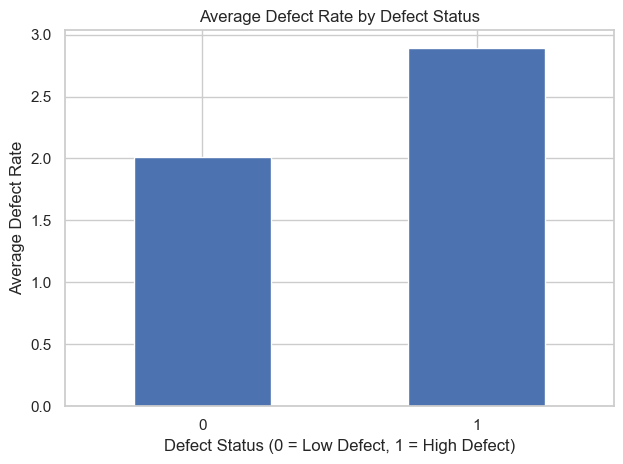

In [19]:
grouped_means["DefectRate"].plot(kind="bar")

plt.title("Average Defect Rate by Defect Status")
plt.xlabel("Defect Status (0 = Low Defect, 1 = High Defect)")
plt.ylabel("Average Defect Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Difference Analysis Between Defect Status Groups

To better understand which variables differ most between low-defect and high-defect records, I calculate both absolute differences and percent differences between the two groups.

In [20]:
difference = grouped_means.loc[1] - grouped_means.loc[0]
percent_difference = (difference / grouped_means.loc[0]) * 100

comparison = pd.DataFrame({
    "Low Defect Avg": grouped_means.loc[0],
    "High Defect Avg": grouped_means.loc[1],
    "Difference": difference,
    "Percent Difference": percent_difference
})

comparison.round(2)

,Low Defect Avg,High Defect Avg,Difference,Percent Difference
DefectRate,2.01,2.89,0.88,43.73
QualityScore,85.44,79.13,-6.32,-7.39
DowntimePercentage,2.49,2.50,0.02,0.65
SupplierQuality,89.33,89.93,0.60,0.67
MaintenanceHours,6.79,12.37,5.58,82.09
WorkerProductivity,90.11,90.03,-0.08,-0.09
DeliveryDelay,2.54,2.56,0.03,1.00
StockoutRate,0.05,0.05,0.00,6.62
ProductionVolume,470.87,563.27,92.40,19.62


In [21]:
comparison.sort_values("Percent Difference", ascending=False).round(2)

,Low Defect Avg,High Defect Avg,Difference,Percent Difference
MaintenanceHours,6.79,12.37,5.58,82.09
DefectRate,2.01,2.89,0.88,43.73
ProductionVolume,470.87,563.27,92.40,19.62
StockoutRate,0.05,0.05,0.00,6.62
DeliveryDelay,2.54,2.56,0.03,1.00
SupplierQuality,89.33,89.93,0.60,0.67
DowntimePercentage,2.49,2.50,0.02,0.65
WorkerProductivity,90.11,90.03,-0.08,-0.09
QualityScore,85.44,79.13,-6.32,-7.39


### Standardized Difference

To compare group differences across variables with different units and scales, I calculate a standardized difference. This divides the difference between high-defect and low-defect averages by a pooled standard deviation for each variable.

In [22]:
std_by_status = df.groupby("DefectStatus")[[
    "DefectRate",
    "QualityScore",
    "DowntimePercentage",
    "SupplierQuality",
    "MaintenanceHours",
    "WorkerProductivity",
    "DeliveryDelay",
    "StockoutRate",
    "ProductionVolume"
]].std()

pooled_std = ((std_by_status.loc[0] ** 2 + std_by_status.loc[1] ** 2) / 2) ** 0.5

standardized_difference = difference / pooled_std

comparison["Standardized Difference"] = standardized_difference

comparison.sort_values("Standardized Difference", ascending=False).round(2)

,Low Defect Avg,High Defect Avg,Difference,Percent Difference,Standardized Difference
MaintenanceHours,6.79,12.37,5.58,82.09,0.93
DefectRate,2.01,2.89,0.88,43.73,0.75
ProductionVolume,470.87,563.27,92.40,19.62,0.38
StockoutRate,0.05,0.05,0.00,6.62,0.11
SupplierQuality,89.33,89.93,0.60,0.67,0.10
DeliveryDelay,2.54,2.56,0.03,1.00,0.01
DowntimePercentage,2.49,2.50,0.02,0.65,0.01
WorkerProductivity,90.11,90.03,-0.08,-0.09,-0.01
QualityScore,85.44,79.13,-6.32,-7.39,-0.60


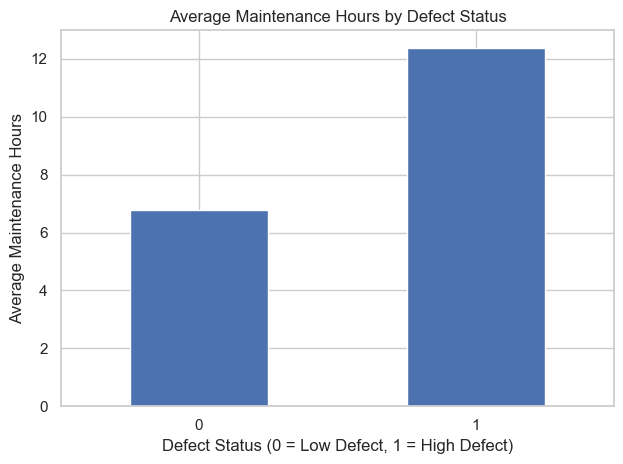

In [23]:
grouped_means["MaintenanceHours"].plot(kind="bar")

plt.title("Average Maintenance Hours by Defect Status")
plt.xlabel("Defect Status (0 = Low Defect, 1 = High Defect)")
plt.ylabel("Average Maintenance Hours")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

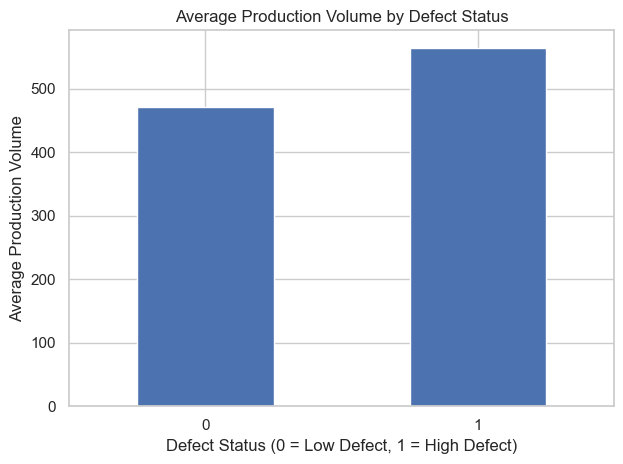

In [24]:
grouped_means["ProductionVolume"].plot(kind="bar")

plt.title("Average Production Volume by Defect Status")
plt.xlabel("Defect Status (0 = Low Defect, 1 = High Defect)")
plt.ylabel("Average Production Volume")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

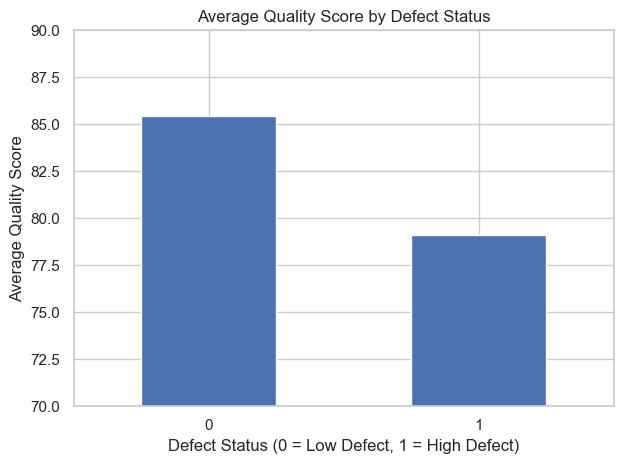

In [25]:
grouped_means["QualityScore"].plot(kind="bar")

plt.title("Average Quality Score by Defect Status")
plt.xlabel("Defect Status (0 = Low Defect, 1 = High Defect)")
plt.ylabel("Average Quality Score")
plt.ylim(70, 90)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Difference Analysis Findings

The difference analysis shows that several variables differ more clearly between low-defect and high-defect records.

`MaintenanceHours` shows the largest relative difference. The high-defect group has substantially higher average maintenance hours than the low-defect group. This may suggest that high-defect records are associated with greater maintenance activity or production issues, although this does not prove causation.

`QualityScore` is lower in the high-defect group, suggesting that lower quality scores are associated with higher defect status in this dataset.

`ProductionVolume` is higher in the high-defect group, which may suggest that higher production volume could be related to increased defect risk or production strain in this synthetic dataset.

In contrast, `DowntimePercentage`, `SupplierQuality`, `WorkerProductivity`, and `DeliveryDelay` show relatively small differences between the two groups. Based on this grouped analysis, these variables do not appear to strongly separate low-defect and high-defect records.

Overall, this analysis suggests that defect status may be associated with multiple production and quality-related variables rather than one single factor.

### Standardized Difference Ranking

Percent differences are useful, but they can exaggerate changes when the baseline value is small. Standardized differences solve this by expressing each group difference in standard-deviation units. This makes variables with different units easier to compare.

In the chart below, positive values mean the high-defect group has a higher average than the low-defect group. Negative values mean the high-defect group has a lower average. The largest absolute values are the variables that separate the two groups most clearly.


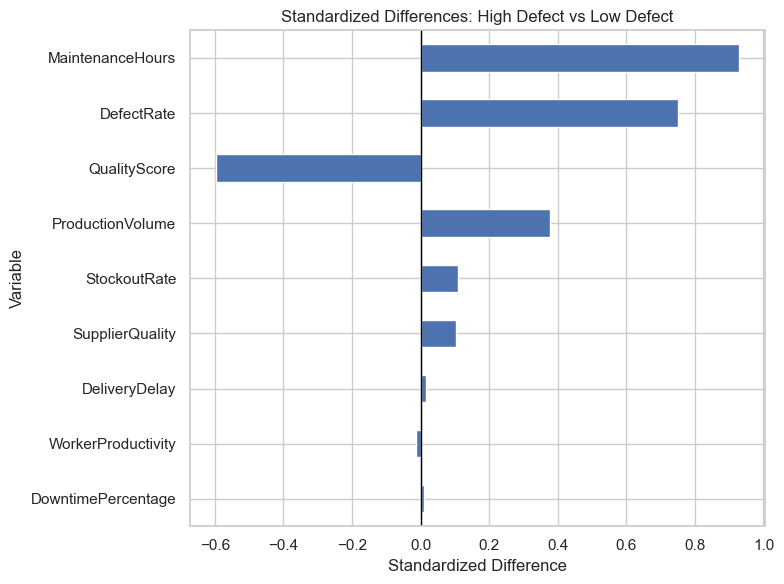

MaintenanceHours      0.927
DefectRate            0.752
QualityScore         -0.598
ProductionVolume      0.377
StockoutRate          0.110
SupplierQuality       0.104
DeliveryDelay         0.015
WorkerProductivity   -0.014
DowntimePercentage    0.011
dtype: float64

In [26]:
standardized_difference_sorted = standardized_difference.sort_values(key=lambda x: x.abs(), ascending=True)

plt.figure(figsize=(8, 6))
standardized_difference_sorted.plot(kind="barh")
plt.axvline(0, color="black", linewidth=1)
plt.title("Standardized Differences: High Defect vs Low Defect")
plt.xlabel("Standardized Difference")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

standardized_difference.sort_values(key=lambda x: x.abs(), ascending=False).round(3)


## 10. Distribution Comparison by Defect Status

The previous grouped analysis compared average values between low-defect and high-defect records. However, averages alone may hide variation within each group. To better understand whether the differences appear across the full distribution, I use boxplots for key variables.

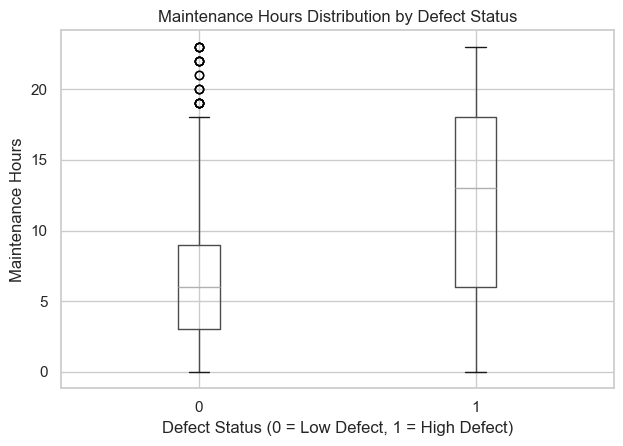

In [27]:
df.boxplot(column="MaintenanceHours", by="DefectStatus")

plt.title("Maintenance Hours Distribution by Defect Status")
plt.suptitle("")
plt.xlabel("Defect Status (0 = Low Defect, 1 = High Defect)")
plt.ylabel("Maintenance Hours")
plt.tight_layout()
plt.show()

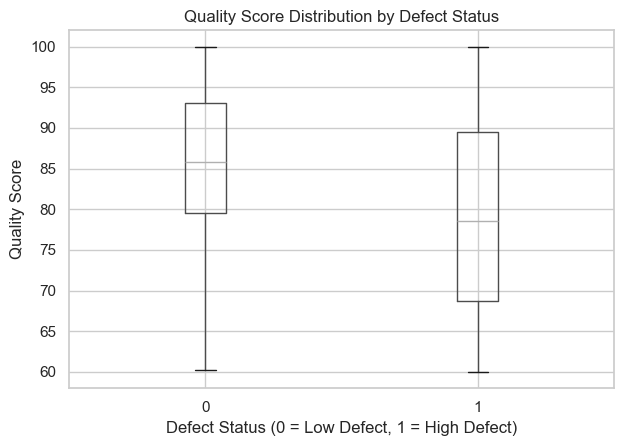

In [28]:
df.boxplot(column="QualityScore", by="DefectStatus")

plt.title("Quality Score Distribution by Defect Status")
plt.suptitle("")
plt.xlabel("Defect Status (0 = Low Defect, 1 = High Defect)")
plt.ylabel("Quality Score")
plt.tight_layout()
plt.show()

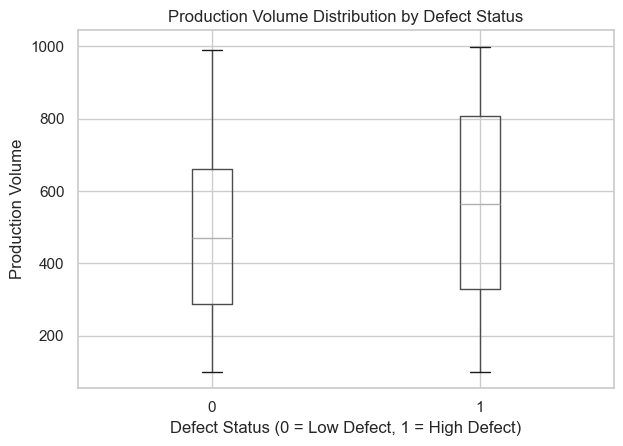

In [29]:
df.boxplot(column="ProductionVolume", by="DefectStatus")

plt.title("Production Volume Distribution by Defect Status")
plt.suptitle("")
plt.xlabel("Defect Status (0 = Low Defect, 1 = High Defect)")
plt.ylabel("Production Volume")
plt.tight_layout()
plt.show()

### Distribution Comparison Findings

The boxplots provide additional context beyond average values. They help show whether differences between low-defect and high-defect records appear across the broader distribution or are mainly driven by mean differences.

For `MaintenanceHours`, the high-defect group appears to have a higher distribution overall, which supports the earlier grouped mean result.

For `QualityScore`, the high-defect group tends to have lower values, which is consistent with the difference analysis.

For `ProductionVolume`, the high-defect group shows higher average production volume, but the distribution should be interpreted carefully because both groups may still have overlapping ranges.

## 11. Summary Statistics by Defect Status

The previous grouped analysis compared average values between low-defect and high-defect records. To better understand the distribution within each group, I also compare the mean, median, standard deviation, and count for selected variables.

In [30]:
summary_by_status = df.groupby("DefectStatus")[[
    "DefectRate",
    "QualityScore",
    "MaintenanceHours",
    "ProductionVolume",
    "DowntimePercentage",
    "SupplierQuality",
    "WorkerProductivity"
]].agg(["mean", "median", "std", "count"])

summary_by_status.round(2)

DefectRate                    QualityScore                      \
                   mean median   std count         mean median    std count   
DefectStatus                                                                  
0                  2.01   1.98  1.00   517        85.44  85.86   9.24   517   
1                  2.89   3.03  1.31  2723        79.13  78.57  11.74  2723   

             MaintenanceHours         ... DowntimePercentage        \
                         mean median  ...                std count   
DefectStatus                          ...                            
0                        6.79    6.0  ...               1.43   517   
1                       12.37   13.0  ...               1.45  2723   

             SupplierQuality                    WorkerProductivity         \
                        mean median   std count               mean median   
DefectStatus                                                                
0                      89.33  88.82  5.79   517              90.11  90.28   
1                      89.93  89.86  5.75  2723              90.03  90.06   

                          
               std count  
DefectStatus              
0             5.72   517  
1             5.73  2723  

[2 rows x 28 columns]

The summary statistics provide a more detailed comparison than averages alone. They show whether group differences are also visible in medians and standard deviations. If both mean and median move in the same direction, the group difference is more consistent. If the standard deviation is large, the variable has substantial variation within each defect-status group.

## 12. Statistical Significance and Effect Size Checks

The earlier sections compare averages, medians, boxplots, and standardized differences. This section adds a statistical check to support those comparisons.

Because the two defect-status groups are imbalanced and the variables may not be normally distributed, I use the Mann-Whitney U test instead of assuming normal distributions. The test checks whether values in the low-defect and high-defect groups tend to come from different distributions.

I also calculate Cohen's d as an effect-size measure. This helps separate statistical significance from practical importance. With thousands of records, very small differences can sometimes become statistically significant, so the effect size is important for interpretation.


In [31]:
test_columns = [
    "DefectRate",
    "QualityScore",
    "MaintenanceHours",
    "ProductionVolume",
    "DowntimePercentage",
    "SupplierQuality",
    "WorkerProductivity",
    "DeliveryDelay",
    "StockoutRate",
]

statistical_results = []

for col in test_columns:
    low = df.loc[df["DefectStatus"] == 0, col]
    high = df.loc[df["DefectStatus"] == 1, col]
    
    u_stat, p_value = mannwhitneyu(low, high, alternative="two-sided")
    
    pooled_std = np.sqrt(((low.std() ** 2) + (high.std() ** 2)) / 2)
    cohens_d = (high.mean() - low.mean()) / pooled_std
    
    statistical_results.append({
        "Variable": col,
        "Low Defect Median": low.median(),
        "High Defect Median": high.median(),
        "Mean Difference": high.mean() - low.mean(),
        "Cohen's d": cohens_d,
        "Mann-Whitney p-value": p_value,
    })

statistical_results_df = pd.DataFrame(statistical_results)
statistical_results_df.sort_values("Cohen's d", key=lambda x: x.abs(), ascending=False).round(4)


,Variable,Low Defect Median,High Defect Median,Mean Difference,Cohen's d,Mann-Whitney p-value
2,MaintenanceHours,6.0000,13.0000,5.5750,0.9273,0.0000
0,DefectRate,1.9776,3.0273,0.8791,0.7518,0.0000
1,QualityScore,85.8639,78.5748,-6.3159,-0.5978,0.0000
3,ProductionVolume,469.0000,565.0000,92.4008,0.3770,0.0000
8,StockoutRate,0.0477,0.0523,0.0032,0.1097,0.0228
5,SupplierQuality,88.8246,89.8606,0.6004,0.1041,0.0280
7,DeliveryDelay,3.0000,3.0000,0.0253,0.0149,0.7488
6,WorkerProductivity,90.2781,90.0625,-0.0816,-0.0143,0.7774
4,DowntimePercentage,2.4075,2.4885,0.0163,0.0113,0.8183


### Statistical Test Interpretation

The statistical test table should be interpreted in two steps. First, the p-value indicates whether the low-defect and high-defect groups show evidence of different distributions for a variable. Second, Cohen's d shows the size and direction of the difference.

For this report, the most useful variables are not just the ones with small p-values. The strongest variables are the ones that also have larger absolute effect sizes. This is why `MaintenanceHours`, `QualityScore`, `DefectRate`, and `ProductionVolume` deserve more attention than variables with very small group differences.


## 13. Correlation Analysis

As a next step, I calculate correlations between selected numerical variables to examine which variables have stronger linear relationships with `DefectRate`.


In [32]:
selected_columns = [
    "DefectRate",
    "QualityScore",
    "DowntimePercentage",
    "SupplierQuality",
    "MaintenanceHours",
    "WorkerProductivity",
    "DeliveryDelay",
    "StockoutRate",
    "ProductionVolume"
]

df[selected_columns].corr()

,DefectRate,QualityScore,DowntimePercentage,SupplierQuality,MaintenanceHours,WorkerProductivity,DeliveryDelay,StockoutRate,ProductionVolume
DefectRate,1.000000,-0.036350,-0.011208,0.012157,-0.008687,-0.000388,-0.023024,0.007547,-0.019360
QualityScore,-0.036350,1.000000,-0.000505,-0.029330,-0.013366,0.004591,0.017268,-0.035049,0.017826
DowntimePercentage,-0.011208,-0.000505,1.000000,0.006298,-0.020494,-0.037814,0.046247,0.001578,0.019905
SupplierQuality,0.012157,-0.029330,0.006298,1.000000,-0.019626,-0.017389,0.014233,-0.001393,-0.026559
MaintenanceHours,-0.008687,-0.013366,-0.020494,-0.019626,1.000000,0.009622,0.018144,0.019251,-0.004554
WorkerProductivity,-0.000388,0.004591,-0.037814,-0.017389,0.009622,1.000000,-0.013869,-0.035034,0.004754
DeliveryDelay,-0.023024,0.017268,0.046247,0.014233,0.018144,-0.013869,1.000000,-0.002767,0.016193
StockoutRate,0.007547,-0.035049,0.001578,-0.001393,0.019251,-0.035034,-0.002767,1.000000,-0.002637
ProductionVolume,-0.019360,0.017826,0.019905,-0.026559,-0.004554,0.004754,0.016193,-0.002637,1.000000


### Correlation with Defect Rate

To focus the correlation analysis, I isolate the correlations between `DefectRate` and the other selected numerical variables.

In [33]:
correlation_with_defect_rate = df[selected_columns].corr()["DefectRate"].sort_values(ascending=False)

correlation_with_defect_rate

DefectRate            1.000000
SupplierQuality       0.012157
StockoutRate          0.007547
WorkerProductivity   -0.000388
MaintenanceHours     -0.008687
DowntimePercentage   -0.011208
ProductionVolume     -0.019360
DeliveryDelay        -0.023024
QualityScore         -0.036350
Name: DefectRate, dtype: float64

### Correlation with Defect Status

Since `DefectStatus` is the main classification variable in this analysis, I also examine which variables have stronger linear relationships with low-defect versus high-defect status.

In [34]:
status_columns = [
    "DefectStatus",
    "DefectRate",
    "QualityScore",
    "DowntimePercentage",
    "SupplierQuality",
    "MaintenanceHours",
    "WorkerProductivity",
    "DeliveryDelay",
    "StockoutRate",
    "ProductionVolume"
]

correlation_with_status = df[status_columns].corr()["DefectStatus"].sort_values(ascending=False)

correlation_with_status

DefectStatus          1.000000
MaintenanceHours      0.297107
DefectRate            0.245746
ProductionVolume      0.128973
StockoutRate          0.040574
SupplierQuality       0.038184
DeliveryDelay         0.005425
DowntimePercentage    0.004128
WorkerProductivity   -0.005224
QualityScore         -0.199219
Name: DefectStatus, dtype: float64

### Correlation Heatmap

The correlation tables show exact values, but a heatmap makes the overall relationship structure easier to scan. Darker positive or negative colors indicate stronger linear relationships.

This heatmap is mainly exploratory. A weak correlation does not mean a variable is useless, because relationships can be nonlinear or only visible when multiple variables are considered together. However, the heatmap is helpful for identifying possible redundancy between variables and for checking whether the dataset has strong linear patterns.


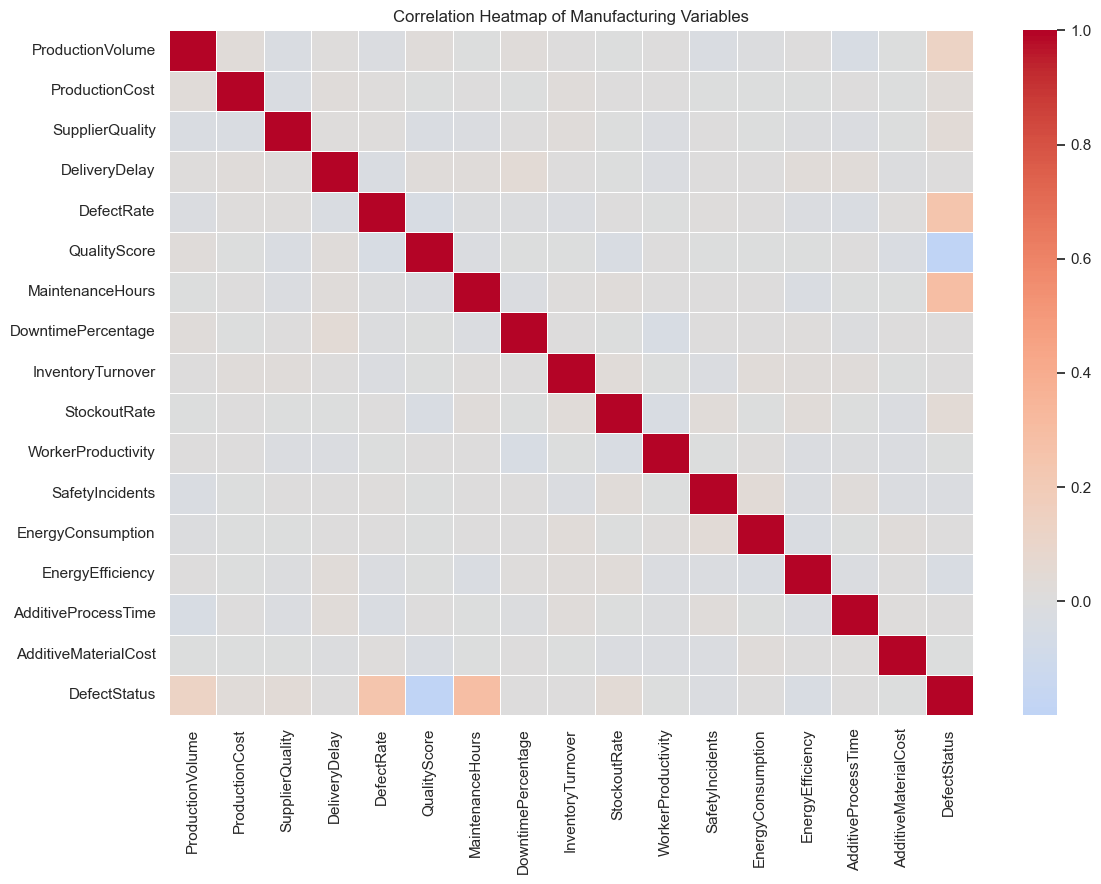

In [35]:
plt.figure(figsize=(12, 9))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Correlation Heatmap of Manufacturing Variables")
plt.tight_layout()
plt.show()


## 14. Correlation Analysis Findings

The correlation analysis shows that most selected variables have weak linear relationships with `DefectRate`. This is consistent with the earlier scatter plots, which did not show clear single-variable linear patterns.

However, this does not contradict the grouped analysis. Correlation with `DefectRate` measures simple linear relationships with a continuous variable, while grouped analysis compares average values between low-defect and high-defect records based on `DefectStatus`.

The correlation with `DefectStatus` is more useful for this project because much of the analysis compares low-defect and high-defect records. The variables with clearer relationships to `DefectStatus` are `MaintenanceHours`, `DefectRate`, `QualityScore`, and `ProductionVolume`.

Together, these results suggest that defect outcomes may be associated with multiple production, quality, and maintenance-related factors rather than one isolated numerical variable.


## 15. Overall High-Defect Profile

Based on the grouped means, difference analysis, distribution comparison, summary statistics, statistical checks, and correlation analysis, high-defect records in this synthetic dataset appear to be associated with:

- Higher maintenance hours
- Lower quality scores
- Higher production volume
- Higher defect rate, which is expected based on the defect classification

Variables such as downtime percentage, supplier quality, worker productivity, and delivery delay show much smaller differences between low-defect and high-defect records.

Overall, the results suggest that defect status may be associated with a combination of production load, maintenance activity, and quality performance rather than one isolated variable.


## 16. Baseline Classification Model

The exploratory analysis suggests that high-defect records differ from low-defect records in several variables. A baseline classification model tests whether these variables work together to distinguish the two groups.

I build two simple models: logistic regression and random forest. Logistic regression is useful because it is interpretable and shows the direction of relationships. Random forest is useful because it can capture nonlinear relationships and interactions between variables.

I exclude `DefectStatus` because it is the target variable. I also exclude `DefectRate` in the main model because it may be directly related to how `DefectStatus` was created. Including it could make the model look better than it really is by leaking information from the target definition.


In [43]:
target = "DefectStatus"

model_features = [
    "ProductionVolume",
    "ProductionCost",
    "SupplierQuality",
    "DeliveryDelay",
    "QualityScore",
    "MaintenanceHours",
    "DowntimePercentage",
    "InventoryTurnover",
    "StockoutRate",
    "WorkerProductivity",
    "SafetyIncidents",
    "EnergyConsumption",
    "EnergyEfficiency",
    "AdditiveProcessTime",
    "AdditiveMaterialCost",
]

X = df[model_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

baseline_accuracy = y_test.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline_accuracy:.3f}")


Majority-class baseline accuracy: 0.841


In [37]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
}

model_results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Average Precision": average_precision_score(y_test, y_proba),
    })

pd.DataFrame(model_results).round(3)


,Model,Accuracy,ROC-AUC,Average Precision
0,Logistic Regression,0.707,0.768,0.937
1,Random Forest,0.844,0.792,0.932


In [38]:
best_model = random_forest_model
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Low Defect", "High Defect"]))

confusion = confusion_matrix(y_test, y_pred)
pd.DataFrame(
    confusion,
    index=["Actual Low Defect", "Actual High Defect"],
    columns=["Predicted Low Defect", "Predicted High Defect"],
)


              precision    recall  f1-score   support

  Low Defect       0.52      0.33      0.40       103
 High Defect       0.88      0.94      0.91       545

    accuracy                           0.84       648
   macro avg       0.70      0.64      0.66       648
weighted avg       0.82      0.84      0.83       648



,Predicted Low Defect,Predicted High Defect
Actual Low Defect,34,69
Actual High Defect,32,513


### Model Interpretation

The classification model should not be treated as a production-ready prediction system. Its purpose is to deepen the exploratory report by checking whether the patterns found earlier remain useful when multiple variables are considered at the same time.

Because the dataset is imbalanced, the most important results are not just accuracy. Precision, recall, F1-score, ROC-AUC, and average precision provide a more honest view of model performance. In this run, the random forest achieved higher accuracy than logistic regression, while both models produced ROC-AUC values around 0.77-0.79 and high average precision because the high-defect class is the majority class.

The random forest still struggles with the minority low-defect class. Its recall for low-defect records is 0.33, meaning it misses many low-defect cases. This confirms that the model is useful as a baseline analytical check, but it should not be treated as a final deployment-ready classifier.


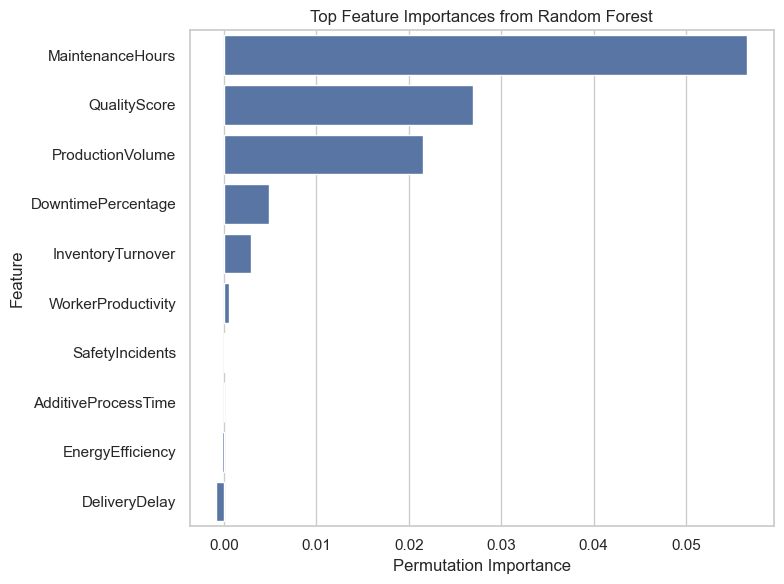

,Feature,Importance,Std
5,MaintenanceHours,0.0567,0.0098
4,QualityScore,0.0270,0.0096
0,ProductionVolume,0.0215,0.0062
6,DowntimePercentage,0.0048,0.0020
7,InventoryTurnover,0.0029,0.0027
9,WorkerProductivity,0.0005,0.0033
10,SafetyIncidents,0.0001,0.0021
13,AdditiveProcessTime,-0.0000,0.0034
12,EnergyEfficiency,-0.0002,0.0034
3,DeliveryDelay,-0.0009,0.0022


In [39]:
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision",
)

importance_df = pd.DataFrame({
    "Feature": model_features,
    "Importance": perm_importance.importances_mean,
    "Std": perm_importance.importances_std,
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
plt.title("Top Feature Importances from Random Forest")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importance_df.round(4)


## 17. Expanded Final Interpretation

The deeper analysis supports the same broad conclusion as the original exploratory work: high-defect records are not explained by one single variable. Instead, defect status appears to be associated with a combination of maintenance activity, quality performance, and production scale.

`MaintenanceHours` is especially important because it shows the strongest standardized difference and the largest Cohen's d among the selected variables. A manufacturing interpretation is that higher maintenance hours may indicate unstable equipment, more frequent interventions, or reactive maintenance after problems occur. This does not prove maintenance causes defects; it may mean that defect-prone processes require more maintenance.

`QualityScore` is also important because high-defect records tend to have lower quality scores. This supports the internal consistency of the dataset: records labeled as high-defect also tend to show weaker quality performance.

`ProductionVolume` adds an operational perspective. High-defect records have higher average production volume in this dataset, which may suggest that production scale, workload, or process intensity is associated with quality outcomes. In a real manufacturing setting, this would motivate further analysis by production line, machine, shift, product type, or batch.

The model section adds one more layer: it tests whether multiple variables together can classify defect status better than a simple majority-class baseline. The model results and permutation importance ranking support the exploratory findings because `MaintenanceHours`, `QualityScore`, and `ProductionVolume` are also the most important features in the random forest model.


## 18. Limitations

This dataset is synthetic, so the findings should be interpreted as exploratory rather than as real-world manufacturing conclusions.

The analysis identifies associations between variables and defect status, but it does not prove causation. For example, higher maintenance hours may be associated with high-defect records, but this does not necessarily mean maintenance causes defects. It may also indicate that machines or processes with more issues require more maintenance.

The dataset is imbalanced, with high-defect records making up about 84% of the data. Because of this imbalance, group comparisons and model metrics should be interpreted carefully. Accuracy alone is not enough to evaluate the baseline classifier, and the model still has limited recall for the minority low-defect class.

The baseline models are included to support the exploratory analysis, not to create a production-ready prediction system. Future analysis could extend this work with cross-validation, hyperparameter tuning, stronger class-imbalance handling, feature engineering, and validation on real manufacturing data.
